# Homework 2 — Company Deep Dive: Petrobras (PBR-A)


Student ID ending with 0 → Group 1 (LATAM & Offshore: Brazil, Mexico, Cayman Islands, Bermuda).

**Selected company:** Petróleo Brasileiro S.A. — Petrobras (`PBR-A`), Brazil. Sector: Energy. Industry: Oil & Gas Integrated.

Why I picked it:

1. Largest market cap in the geographic group (~$121B). It is the dominant LATAM name in the dataset and it lets me compare against global oil majors.
2. All eight metrics required by the assignment are available for PBR-A. The other large candidates in the group, ITUB (Itaú) and NU (Nu Holdings), both miss `debt_to_equity` and `free_cashflow`, so BQ4 would not be doable on them.
3. The same-industry peer set is small (8 integrated oil & gas companies worldwide with valid market cap) but high quality: Exxon, Chevron, the three Canadian integrateds (Suncor, Imperial Oil, Cenovus), plus a couple of US small caps. The PDF explicitly allows fewer than 10 peers when the industry universe is limited.

**Link with Homework 1.** In HW1 I did a sector deep dive on Utilities with a geopolitical framing around the Strait of Hormuz and oil prices. Petrobras sits on the other side of that same theme — a national oil major exposed to crude prices and country risk in an emerging market — so HW2 and HW1 talk to each other in a natural way without forcing the narrative.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# I keep the chart defaults I used in HW1 so the two notebooks look similar.
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False

# Small helpers I reuse from HW1: axis formatters and a function to drop the
# top/right spines.
def billions_formatter(x, pos):
    return f"{x/1e9:,.1f}B"

def pct_formatter(x, pos):
    return f"{x:.1f}%"

def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

In [47]:
# Load the dataset and keep only the columns required for this homework.
raw = pd.read_csv("Symbol_Info_extended.csv")

cols = ["symbol", "company_name", "sector", "industry", "country", "market_cap",
        "return_on_assets", "return_on_equity", "profit_margins",
        "pe_trailing", "price_to_book", "revenue_growth",
        "debt_to_equity", "free_cashflow"]

df = raw[cols].copy()

# Global cleaning: replace inf and -inf with NaN. They show up when a ratio is
# computed from a zero denominator and they would break sorting. The other two
# cleaning rules from the PDF (market_cap<=0 for peers, pe<=0 and pb<=0 for
# valuation charts) I apply only at the step where they are needed.
df = df.replace([np.inf, -np.inf], np.nan)

print("Working dataset shape:", df.shape)

Working dataset shape: (3070, 14)


In [48]:
# My company. I keep the ticker in a constant so I do not have to retype it.
TICKER = "PBR-A"
me = df[df["symbol"] == TICKER].iloc[0]

print(f"{TICKER} — {me['company_name']}")
print(f"  sector / industry: {me['sector']} / {me['industry']}")
print(f"  country: {me['country']}")
print(f"  market_cap: {me['market_cap']/1e9:.1f} B USD")

# Quick availability check on the 8 metrics required by the homework.
# If something were missing I would declare it and plot peers only.
metrics = ["return_on_assets", "return_on_equity", "profit_margins",
           "pe_trailing", "price_to_book", "revenue_growth",
           "debt_to_equity", "free_cashflow"]
availability = pd.DataFrame({
    "metric": metrics,
    "value": [me[m] for m in metrics],
    "available": [pd.notna(me[m]) for m in metrics]
})
availability

PBR-A — Petróleo Brasileiro S.A. - Petrobras
  sector / industry: Energy / Oil & Gas Integrated
  country: Brazil
  market_cap: 121.3 B USD


,metric,value,available
0,return_on_assets,8.231000e-02,True
1,return_on_equity,2.560100e-01,True
2,profit_margins,2.159900e-01,True
3,pe_trailing,5.469136e+00,True
4,price_to_book,1.369260e+00,True
5,revenue_growth,4.000000e-03,True
6,debt_to_equity,8.326900e+01,True
7,free_cashflow,8.293275e+10,True


In [49]:
# Group A: same industry as my company, top 10 by market cap. The PDF says I
# must add my company if it is not in the top 10. I also exclude market_cap<=0
# from the pool because the PDF treats it as a data quality issue.
industry_me = me["industry"]
pool_a = df[(df["industry"] == industry_me) & (df["market_cap"] > 0)].copy()

top10_a = pool_a.sort_values("market_cap", ascending=False).head(10)

if TICKER not in top10_a["symbol"].values:
    group_a = pd.concat([top10_a, pool_a[pool_a["symbol"] == TICKER]])
else:
    group_a = top10_a

group_a = group_a.reset_index(drop=True)

# Note: Oil & Gas Integrated has only 8 companies worldwide with valid market
# cap in the dataset, so Group A has 8 names. The PDF allows this case.
print(f"Group A — same industry ({industry_me}): {len(group_a)} companies")
group_a[["symbol", "company_name", "country", "market_cap"]]

Group A — same industry (Oil & Gas Integrated): 8 companies


,symbol,company_name,country,market_cap
0,XOM,Exxon Mobil Corporation,United States,6.421352e+11
1,CVX,Chevron Corporation,United States,3.812515e+11
2,PBR-A,Petróleo Brasileiro S.A. - Petrobras,Brazil,1.213202e+11
3,SU,Suncor Energy Inc.,Canada,7.951138e+10
4,IMO,Imperial Oil Limited,Canada,6.622713e+10
5,CVE,Cenovus Energy Inc.,Canada,5.603781e+10
6,NFG,National Fuel Gas Company,United States,7.690261e+09
7,DEC,Diversified Energy Company,United States,1.120291e+09


In [50]:
# Group B: same geographic group as my company. My Student ID ends with 0, so
# Group 1 = LATAM & Offshore = Brazil, Mexico, Cayman Islands, Bermuda.
# Same logic as Group A: top 10 by market cap, plus me if I am not in the top 10.
group1_countries = ["Brazil", "Mexico", "Cayman Islands", "Bermuda"]
pool_b = df[df["country"].isin(group1_countries) & (df["market_cap"] > 0)].copy()

top10_b = pool_b.sort_values("market_cap", ascending=False).head(10)

if TICKER not in top10_b["symbol"].values:
    group_b = pd.concat([top10_b, pool_b[pool_b["symbol"] == TICKER]])
else:
    group_b = top10_b

group_b = group_b.reset_index(drop=True)
print(f"Group B — same geographic group (LATAM & Offshore): {len(group_b)} companies")
group_b[["symbol", "company_name", "country", "industry", "market_cap"]]

Group B — same geographic group (LATAM & Offshore): 10 companies


,symbol,company_name,country,industry,market_cap
0,PBR-A,Petróleo Brasileiro S.A. - Petrobras,Brazil,Oil & Gas Integrated,1.213202e+11
1,ITUB,Itaú Unibanco Holding S.A.,Brazil,Banks - Regional,8.618888e+10
2,AMX,"América Móvil, S.A.B. de C.V.",Mexico,Telecom Services,7.858860e+10
3,VALE,Vale S.A.,Brazil,Other Industrial Metals & Mining,7.025672e+10
4,NU,Nu Holdings Ltd.,Brazil,Banks - Regional,6.188996e+10
5,ABEV,Ambev S.A.,Brazil,Beverages - Brewers,4.983262e+10
6,CRDO,Credo Technology Group Holding Ltd,Cayman Islands,Semiconductors,4.028571e+10
7,VIK,Viking Holdings Ltd,Bermuda,Travel Services,3.757982e+10
8,BBD,Banco Bradesco S.A.,Brazil,Banks - Regional,3.668037e+10
9,ACGL,Arch Capital Group Ltd.,Bermuda,Insurance - Diversified,3.364622e+10


In [51]:
# Group C: 10 companies with the closest market cap to mine, measured as
# absolute distance. I exclude market_cap<=0 from the pool. My company has
# distance 0 by construction, so it appears as the first row and the group
# size is 10 total (PBR-A + 9 closest peers), as the PDF requires.
pool_c = df[df["market_cap"] > 0].copy()
pool_c["cap_distance"] = (pool_c["market_cap"] - me["market_cap"]).abs()

group_c = pool_c.sort_values("cap_distance").head(10).reset_index(drop=True)
print(f"Group C — closest market cap: {len(group_c)} companies")
group_c[["symbol", "company_name", "country", "industry", "market_cap", "cap_distance"]]

Group C — closest market cap: 10 companies


,symbol,company_name,country,industry,market_cap,cap_distance
0,PBR-A,Petróleo Brasileiro S.A. - Petrobras,Brazil,Oil & Gas Integrated,1.213202e+11,0.000000e+00
1,SYK,Stryker Corporation,United States,Medical Devices,1.213260e+11,5.791744e+06
2,BMY,Bristol-Myers Squibb Company,United States,Drug Manufacturers - General,1.214216e+11,1.013268e+08
3,DHR,Danaher Corporation,United States,Diagnostics & Research,1.217365e+11,4.163174e+08
4,LOW,"Lowe's Companies, Inc.",United States,Home Improvement Retail,1.206318e+11,6.883983e+08
5,LMT,Lockheed Martin Corporation,United States,Aerospace & Defense,1.229457e+11,1.625514e+09
6,MO,"Altria Group, Inc.",United States,Tobacco,1.234050e+11,2.084733e+09
7,SPGI,S&P Global Inc.,United States,Financial Data & Stock Exchanges,1.236096e+11,2.289377e+09
8,CVS,CVS Health Corporation,United States,Healthcare Plans,1.189930e+11,2.327241e+09
9,BKNG,Booking Holdings Inc.,United States,Travel Services,1.248019e+11,3.481698e+09


In [52]:
# Highlight colors I will reuse across all peer-group charts. Dark orange for
# my company, neutral gray for peers.
HIGHLIGHT = "#D9531E"
PEER = "#9CA3AF"

def hbar_metric(group, metric, ax, xlabel, scale=100, xfmt=None, zero_line=True):
    # Drop only the rows missing this specific metric, as the PDF requires.
    # Default scale is 100 because profitability and growth values are decimals
    # in the dataset (0.21 = 21%). For metrics already in their natural unit
    # (P/E, P/B, D/E which is already in percent), I pass scale=1.
    sub = group.dropna(subset=[metric]).copy()
    sub["v"] = sub[metric] * scale
    sub = sub.sort_values("v", ascending=True).reset_index(drop=True)
    sub["label"] = sub["company_name"].fillna(sub["symbol"])

    colors = [HIGHLIGHT if s == TICKER else PEER for s in sub["symbol"]]
    ax.barh(sub["label"], sub["v"], color=colors)
    ax.set_xlabel(xlabel)
    if xfmt is not None:
        ax.xaxis.set_major_formatter(FuncFormatter(xfmt))
    if zero_line:
        ax.axvline(0, color="black", linewidth=0.6)
    ax.grid(axis="x", alpha=0.25)
    clean_spines(ax)

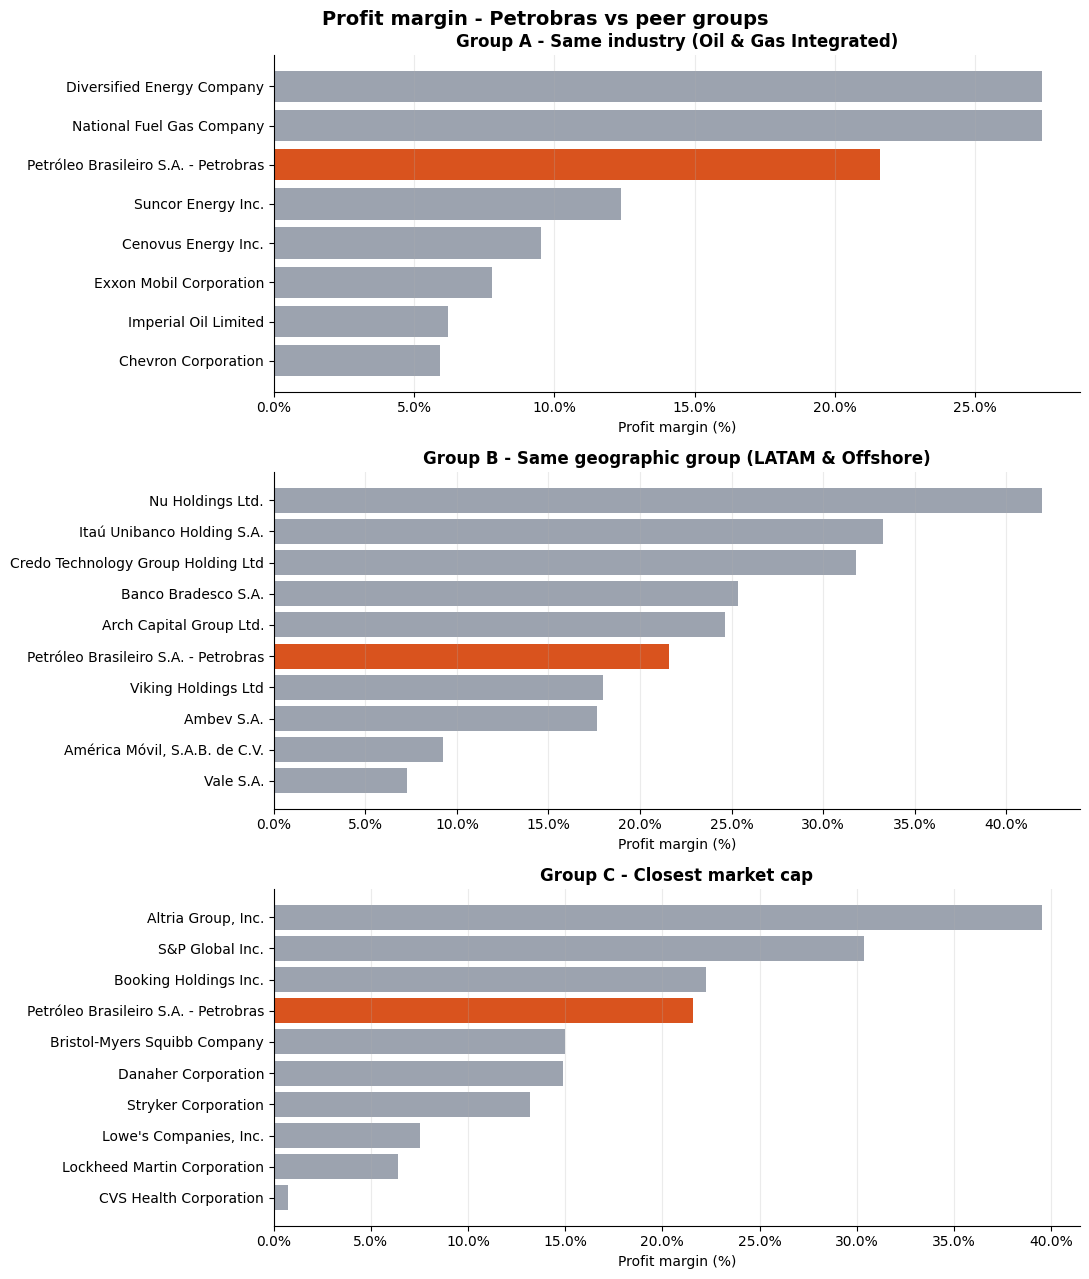

In [53]:
# BQ1 - metric 1: profit_margins. Three charts stacked, one per peer group.
fig, axes = plt.subplots(3, 1, figsize=(11, 13))

hbar_metric(group_a, "profit_margins", axes[0], "Profit margin (%)", xfmt=pct_formatter)
axes[0].set_title("Group A - Same industry (Oil & Gas Integrated)")

hbar_metric(group_b, "profit_margins", axes[1], "Profit margin (%)", xfmt=pct_formatter)
axes[1].set_title("Group B - Same geographic group (LATAM & Offshore)")

hbar_metric(group_c, "profit_margins", axes[2], "Profit margin (%)", xfmt=pct_formatter)
axes[2].set_title("Group C - Closest market cap")

fig.suptitle("Profit margin - Petrobras vs peer groups", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

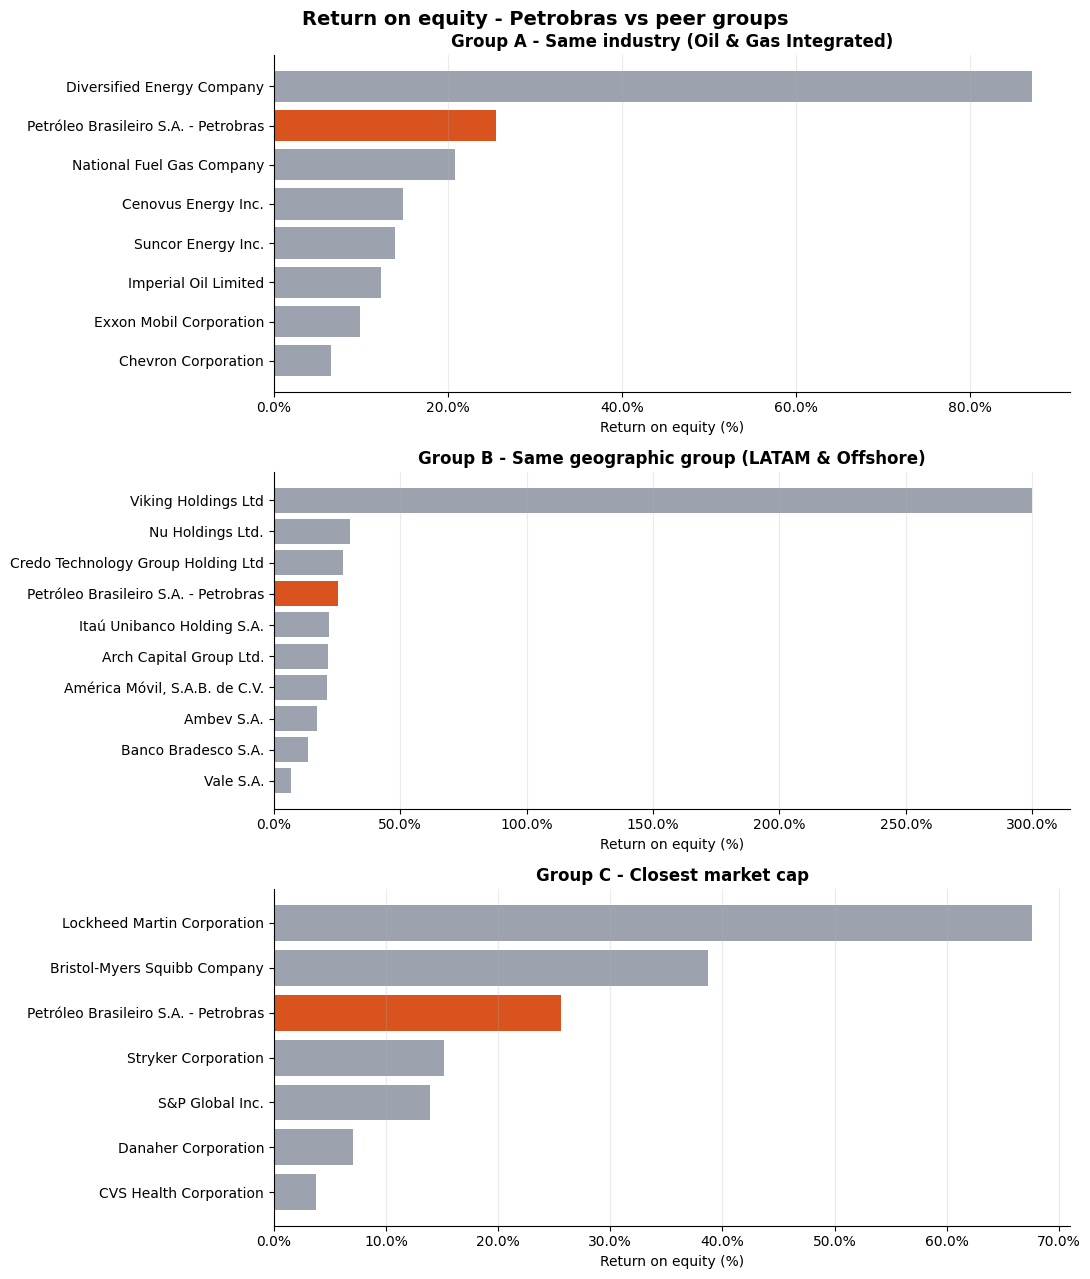

In [54]:
# BQ1 - metric 2: return_on_equity. The PDF notes that ~26% of companies in
# the full dataset have negative ROE because of losses or negative book equity.
# My peer groups can include negatives, so I keep the zero line visible.
# Note on missing values: three names in Group C (LOW, MO, BKNG) have NaN ROE
# in the dataset, most likely from negative book equity after years of heavy
# share buybacks. The Group C chart will show 7 bars only.
fig, axes = plt.subplots(3, 1, figsize=(11, 13))

hbar_metric(group_a, "return_on_equity", axes[0], "Return on equity (%)", xfmt=pct_formatter)
axes[0].set_title("Group A - Same industry (Oil & Gas Integrated)")

hbar_metric(group_b, "return_on_equity", axes[1], "Return on equity (%)", xfmt=pct_formatter)
axes[1].set_title("Group B - Same geographic group (LATAM & Offshore)")

hbar_metric(group_c, "return_on_equity", axes[2], "Return on equity (%)", xfmt=pct_formatter)
axes[2].set_title("Group C - Closest market cap")

fig.suptitle("Return on equity - Petrobras vs peer groups", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## BQ1 — Profitability: interpretation

Petrobras has a profit margin of 21.6% and a return on equity of 25.6%. Both look strong, but the picture changes a lot depending on which peer cut I use.

**Profit margin.** In Group A (industry) PBR-A is third out of eight, well above the industry median around 11%. Exxon, Chevron and Imperial Oil all sit between 7% and 9%, so Petrobras keeps a bigger share of each dollar of revenue than the western integrated majors. The two names above it (Diversified Energy and National Fuel Gas) are small US specialty plays, not real comparables. In Group B (geography) PBR-A is in the lower half: this is because the geographic set mixes sectors, and Brazilian banks (NU, ITUB, BBD) plus a few asset-light names (CRDO, ACGL) have structurally much higher margins than an oil company. The comparison is not industry-adjusted. In Group C (closest market cap) PBR-A is fourth out of ten, above the median; the firms ahead are Altria, S&P Global and Booking, all very different business models from an oil major.

**Return on equity.** In Group A, PBR-A is second at 25.6%, behind only Diversified Energy (87%, a small US gas player whose ROE is inflated by a very thin equity base). Petrobras' ROE is about 2.5x Exxon (9.9%) and almost 4x Chevron (6.6%): against the global integrated oil majors this is the most striking number of BQ1. In Group B, Viking Holdings sits at around 300% because of a very small post-IPO book equity, and this dominates the chart scale; setting that single outlier aside, PBR-A is in the top half of the LATAM peer set. In Group C, three companies (Lowe's, Altria and Booking) have a missing ROE, likely from negative or near-zero book equity after years of heavy share buybacks. Against the remaining seven names, PBR-A is third and clearly above the peer median.

**Are the two metrics consistent?** Yes. Both rank Petrobras above the median in the industry-relevant comparison (Group A) and against the size-matched peer set (Group C). The only group where the company looks weaker is the geographic one, and that is a sector mix effect rather than a profitability issue. Overall, Petrobras' profitability profile is clearly above the integrated oil majors median on both metrics.

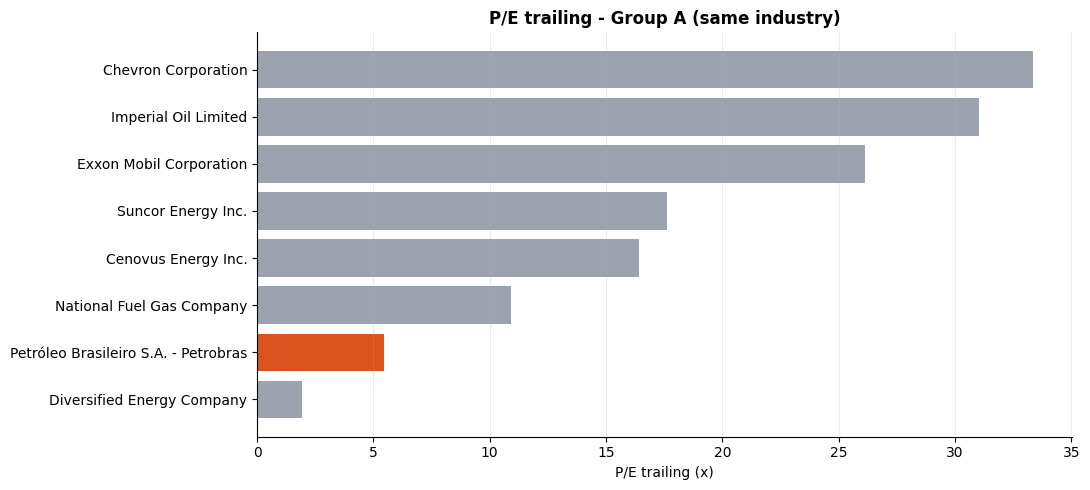

In [55]:
# BQ2 - Valuation, metric 1: pe_trailing. The PDF restricts the valuation
# comparison to Group A (the industry peer set). I set pe<=0 to NaN before
# plotting: a negative P/E only signals losses and is not comparable on the
# same scale as positive multiples.
g_val = group_a.copy()
g_val["pe_trailing"] = g_val["pe_trailing"].where(g_val["pe_trailing"] > 0, np.nan)

fig, ax = plt.subplots(figsize=(11, 5))
hbar_metric(g_val, "pe_trailing", ax, "P/E trailing (x)", scale=1, xfmt=None, zero_line=False)
ax.set_title("P/E trailing - Group A (same industry)")
plt.tight_layout()
plt.show()

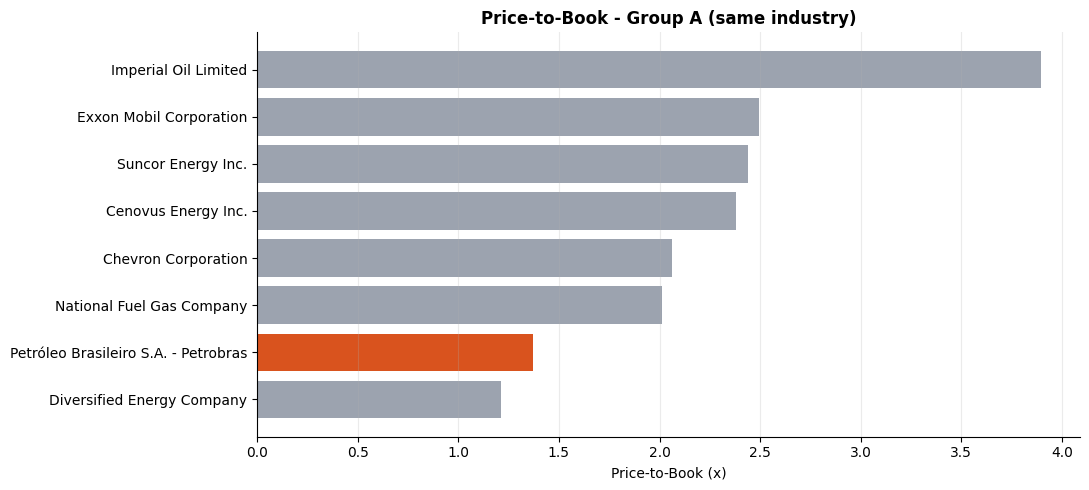

In [56]:
# BQ2 - Valuation, metric 2: price_to_book. Same cleaning rule: a negative P/B
# means negative book equity and is not comparable to positive multiples.
g_val = group_a.copy()
g_val["price_to_book"] = g_val["price_to_book"].where(g_val["price_to_book"] > 0, np.nan)

fig, ax = plt.subplots(figsize=(11, 5))
hbar_metric(g_val, "price_to_book", ax, "Price-to-Book (x)", scale=1, xfmt=None, zero_line=False)
ax.set_title("Price-to-Book - Group A (same industry)")
plt.tight_layout()
plt.show()

## BQ2 — Valuation: interpretation

Within the integrated oil & gas industry (Group A), Petrobras trades at a clear discount on both multiples.

**P/E trailing.** PBR-A is at 5.5x, against an industry median of 17.0x. The only peer cheaper than Petrobras is Diversified Energy at 1.9x, a small US gas company with distressed fundamentals (very high payout ratio, declining production). If I set DEC aside, Petrobras is the cheapest name in the integrated-majors set. Exxon trades at 26x, Chevron at 33x, Imperial Oil at 31x: PBR-A is between three and six times cheaper than the western majors.

**Price-to-Book.** Same story. PBR-A is at 1.37x against a median of 2.22x. Again only DEC sits lower (1.21x). The western majors and the Canadian integrateds all trade between 2x and 4x book.

**Cheap, expensive, or fairly valued?** Cheap. Both multiples place Petrobras in the bottom of its industry peer set, well below the median.

**Does this discount reflect weak fundamentals?** No, and this is the important point. From BQ1, Petrobras' profit margin (21.6%) is twice the industry median, and its ROE (25.6%) is the second highest of the group and almost 4x Chevron's. The discount is not driven by weak profitability. The more likely reasons sit outside the income statement: country risk (Brazil is an emerging market with a higher equity risk premium), political risk (Petrobras is state-controlled and has historically been subject to government interventions on fuel prices), and currency risk (BRL volatility against USD). Whether this gap is a structural penalty or an opportunity is something BQ3 (growth) and BQ4 (debt and free cash flow) will help to clarify.

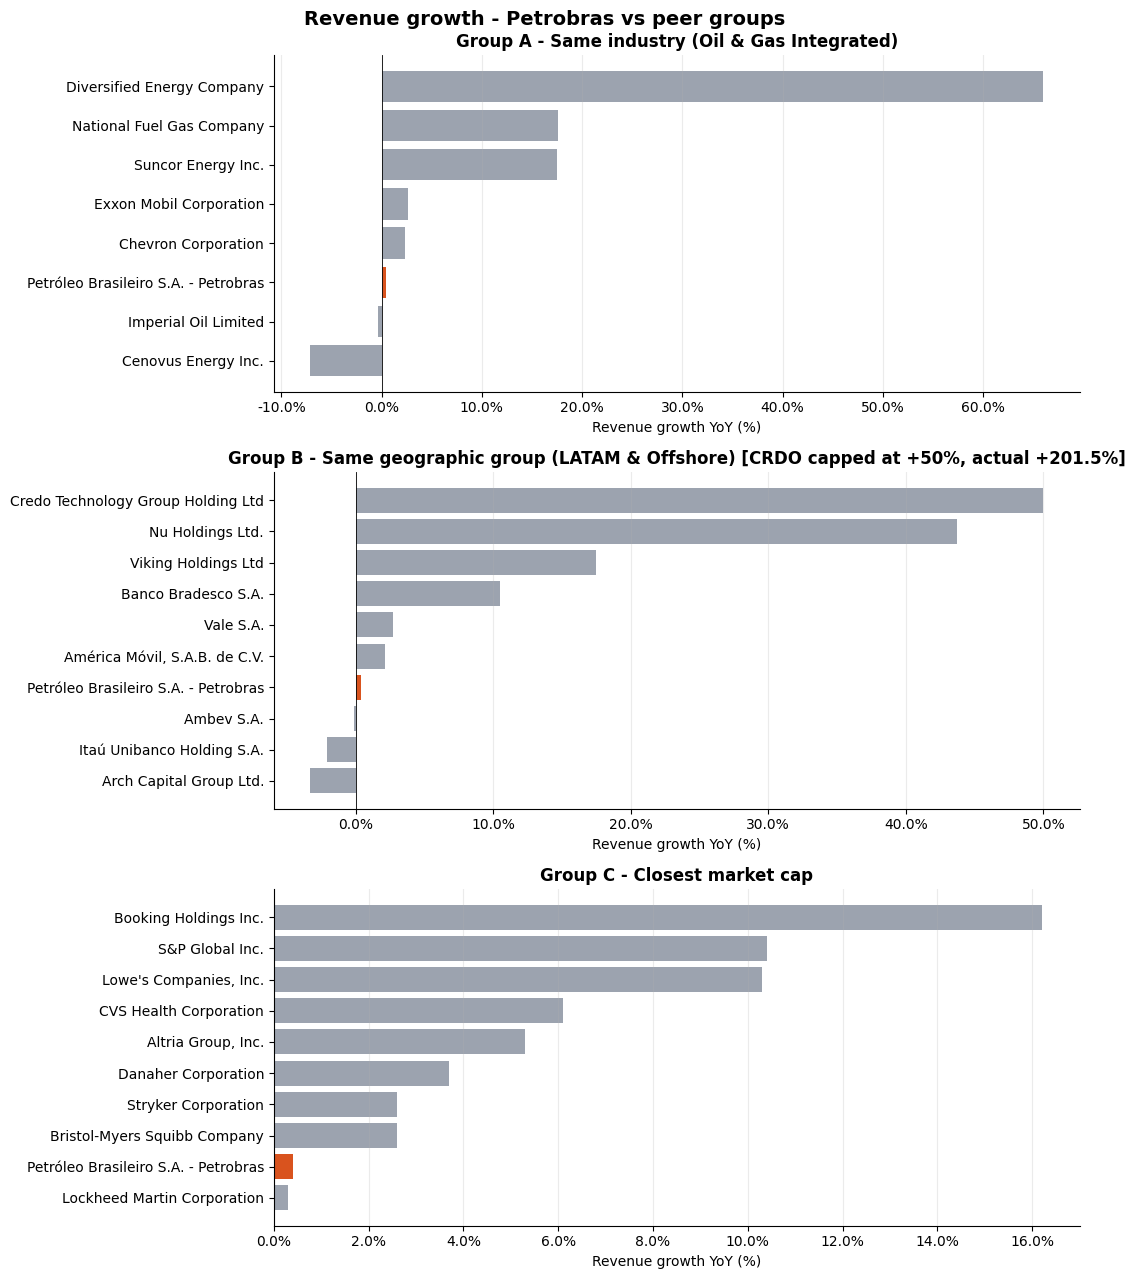

In [57]:
# BQ3 - Growth: revenue_growth on all three peer groups. The PDF allows a cap
# if outliers distort the scale, with the alarm threshold at +1000% (decimal
# 10). None of my peer groups hits that, but Group B contains CRDO (Credo
# Technology) at +201.5%, a recently IPO'd semiconductor in hyper-growth, and
# it would crush the scale for the other peers. I clip its revenue_growth at
# +50% for plotting purposes only and flag the true value in the subplot title.
# Groups A and C have no outlier above the natural chart range, so I plot raw.
group_b_plot = group_b.copy()
group_b_plot["revenue_growth_plot"] = group_b_plot["revenue_growth"].clip(upper=0.50)

fig, axes = plt.subplots(3, 1, figsize=(11, 13))

hbar_metric(group_a, "revenue_growth", axes[0], "Revenue growth YoY (%)", xfmt=pct_formatter)
axes[0].set_title("Group A - Same industry (Oil & Gas Integrated)")

hbar_metric(group_b_plot, "revenue_growth_plot", axes[1], "Revenue growth YoY (%)", xfmt=pct_formatter)
axes[1].set_title("Group B - Same geographic group (LATAM & Offshore) [CRDO capped at +50%, actual +201.5%]")

hbar_metric(group_c, "revenue_growth", axes[2], "Revenue growth YoY (%)", xfmt=pct_formatter)
axes[2].set_title("Group C - Closest market cap")

fig.suptitle("Revenue growth - Petrobras vs peer groups", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## BQ3 — Growth: interpretation

Petrobras grew revenue by +0.4% year-on-year, essentially flat. Across the three peer cuts the company is below the median, but the size of the gap depends a lot on the group.

**Group A (industry).** PBR-A is sixth out of eight at +0.4%, against an industry median of +2.5%. The interesting point inside the integrated oil majors is that Exxon (+2.6%), Chevron (+2.3%) and Imperial Oil (-0.4%) are all in the same flat-growth band as Petrobras. The high-growth peers in the group are special cases: Diversified Energy (+66%) is M&A-driven, National Fuel Gas (+17.6%) benefits from high US gas prices, and Suncor (+17.5%) had a non-recurring year. If I strip those three out, Petrobras grows in line with the western integrated majors.

**Group B (geography).** PBR-A is seventh out of ten, behind CRDO (capped at +50% in the chart against a real +201.5%, a recently IPO'd semiconductor in hyper-growth), Nu Holdings (+43.7%, a digital bank still scaling) and others. This is the cross-sector comparison again: comparing an oil major's revenue trajectory with a digital bank or a semiconductor name mixes very different growth profiles. Among the LATAM names that are comparable in maturity (commodity / industrial), Vale grew +2.7% and AMX +2.1%, both close to Petrobras.

**Group C (closest market cap).** PBR-A is ninth out of ten, against a median of +4.5%. Booking (+16.2%), S&P Global (+10.4%) and Lowe's (+10.3%) are clearly growing faster. This is the cut where Petrobras looks most clearly behind.

**Positive or negative?** Positive, but only just. Petrobras is not declining, but it is far from growth-mode.

**Does growth explain the valuation discount of BQ2?** No, not against the industry peers. Petrobras grows at +0.4% and trades at 5.5x P/E, while Exxon grows at +2.6% and trades at 26x, and Chevron grows at +2.3% and trades at 33x. The two western majors have growth profiles very close to Petrobras, but trade at five to six times the earnings multiple. The discount of BQ2 is therefore not explained by a growth gap with the industry peers. The most likely drivers remain the non-fundamental factors flagged in BQ2 (country risk, political risk, FX). BQ4 will test whether the balance-sheet side of the story — debt and free cash flow — adds anything to the picture.

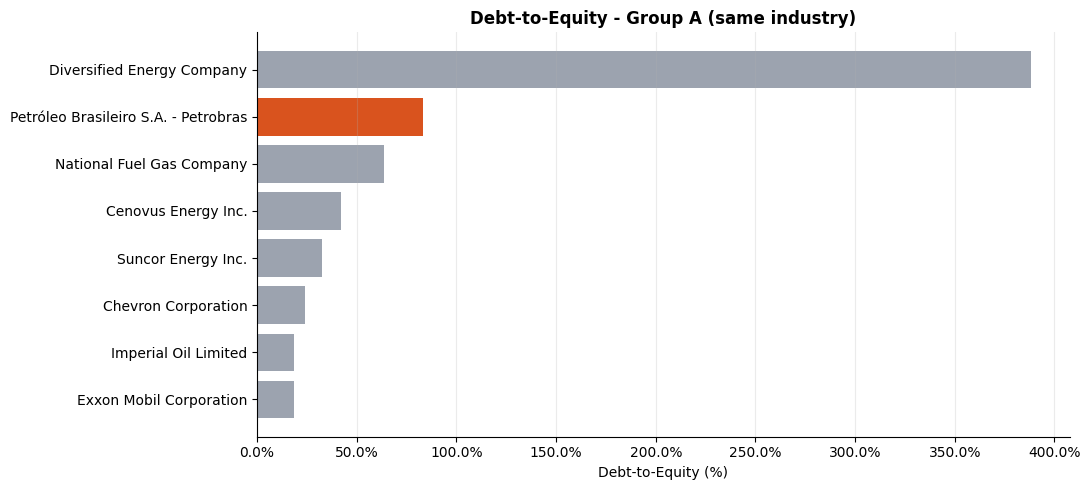

In [58]:
# BQ4 - Financial strength, metric 1: debt_to_equity (Group A only). The
# dataset stores D/E in percentage form already (PBR-A = 83.27 means 83.27%
# = 0.83x ratio), so scale=1 and the axis formatter uses percent. The PDF
# flags outliers above 10,000% to be capped: in my Group A the max is DEC at
# 388%, well below that threshold, so no cap is needed.
fig, ax = plt.subplots(figsize=(11, 5))
hbar_metric(group_a, "debt_to_equity", ax, "Debt-to-Equity (%)",
            scale=1, xfmt=pct_formatter, zero_line=False)
ax.set_title("Debt-to-Equity - Group A (same industry)")
plt.tight_layout()
plt.show()

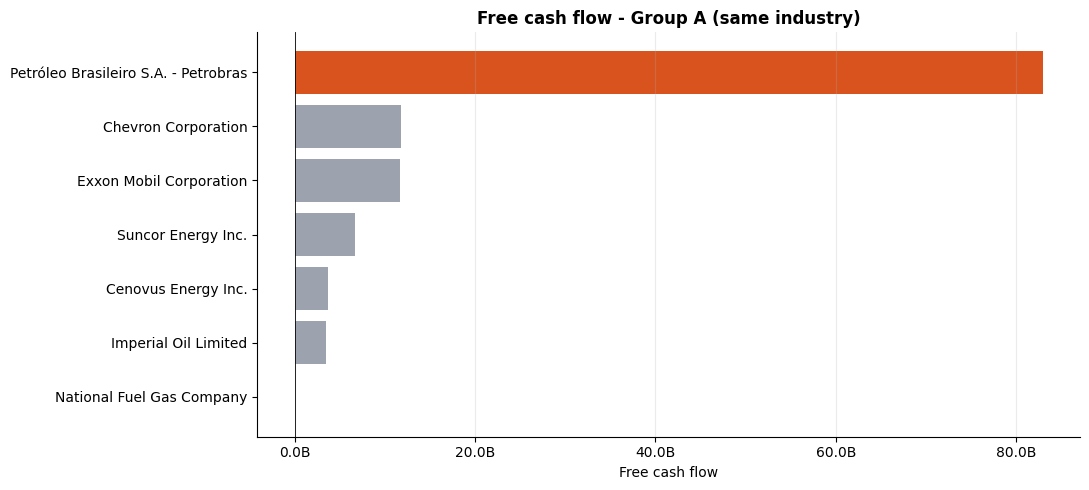

In [59]:
# BQ4 - Financial strength, metric 2: free_cashflow (Group A only). FCF is in
# absolute monetary terms and can be negative, so I keep the zero line. The
# helper passes raw values to the bars and the axis formatter divides by 1e9
# for the display ("82.9B"). One peer (DEC) has NaN FCF and is dropped.
# Important note for the interpretation: the dataset stores FCF in the native
# reporting currency of each company. The US and Canadian peers report in
# USD, Petrobras reports in BRL. I plot raw values from the CSV and adjust
# the comparison verbally in the written interpretation below.
fig, ax = plt.subplots(figsize=(11, 5))
hbar_metric(group_a, "free_cashflow", ax, "Free cash flow",
            scale=1, xfmt=billions_formatter, zero_line=True)
ax.set_title("Free cash flow - Group A (same industry)")
plt.tight_layout()
plt.show()

## BQ4 — Financial solidity: interpretation

**Debt-to-Equity.** Petrobras runs at 83% (0.83x), which makes it the second most leveraged name in Group A after Diversified Energy (388%, a small US gas play in a structurally different capital regime). The big integrated western majors are much more conservative: Exxon 18%, Imperial Oil 18.5%, Chevron 24%. The Canadian integrateds Suncor (32%) and Cenovus (42%) sit in the middle. Against the PDF reference range, PBR-A's 83% falls in the "intermediate" band (50%–200%), not "weak" (>200%). So Petrobras carries meaningfully more debt than its western peers — roughly three to four times the leverage of Exxon and Chevron — but is not in the danger zone, and the level is reasonable for an oil major.

**Free cash flow.** In the raw chart, Petrobras reports the highest FCF in Group A by a wide margin (around 83 billion in its reporting currency). One caveat I want to flag: the dataset stores free cash flow in each company's native reporting currency, and Petrobras reports in BRL while the US and Canadian peers report in USD. A rough USD conversion (around 5 BRL per USD) brings Petrobras' FCF down to about 16 billion USD, which is still the top of the group, ahead of Exxon (11.6B) and Chevron (11.8B), but the lead is much smaller than the raw chart suggests. Even on a like-for-like USD basis, FCF generation is solid, comfortably positive and above the integrated-majors median. The only peer with negative FCF is National Fuel Gas, and it is essentially at zero rather than meaningfully negative.

**Strong, weak, or mixed?** Mixed, but the positives clearly outweigh the negatives. Petrobras runs more leverage than the western majors — this is the main balance-sheet concern — but the leverage is in the intermediate band of the PDF reference range, not extreme. On the cash side the company is a strong generator of free cash flow, also after adjusting for the currency mismatch with the rest of the group.

**Tying it back to BQ2.** Combined with BQ1 (profit margin 21.6%, ROE 25.6%) and BQ3 (growth in line with the western majors), the financial profile does not justify the valuation discount of BQ2. A company with above-industry margins, top-of-group ROE, ~16 billion USD-equivalent FCF and 83% debt-to-equity is closer to a "moderately leveraged value play" than a "distressed value trap". The discount of BQ2 keeps pointing at the structural risk factors flagged earlier — country risk, political risk and FX — rather than at fundamentals.

## Final Summary

### Why Petrobras

My Student ID ends with 0, so I was assigned to Group 1 (LATAM & Offshore: Brazil, Mexico, Cayman Islands, Bermuda). Inside the group, the dataset contains 57 companies, with the few really large LATAM names concentrated in Brazil. I selected **Petrobras (PBR-A)** for three reasons. First, it is the largest market cap in the geographic group (~$121B), so it represents LATAM well and lets me compare against the global integrated oil majors. Second, all eight metrics required by the assignment are available in the dataset for PBR-A: this matters because two of the other large LATAM candidates, Itaú Unibanco and Nu Holdings, miss both debt_to_equity and free_cashflow, which would make BQ4 impossible. Third, the same-industry peer set is small (8 companies worldwide with valid market cap, and the PDF explicitly allows fewer than 10) but high quality, with Exxon, Chevron and the three Canadian integrateds as direct comparables.

**Connection with Homework 1.** In HW1 I worked on the Utilities sector with a geopolitical framing around the Strait of Hormuz and oil price exposure. Petrobras is the follow-up on the company side: a national oil major in an emerging market, fully exposed to crude prices and to country risk. The same theme of energy markets and geopolitical risk premium that shaped HW1 also helps explain a meaningful part of the valuation gap I find for Petrobras in HW2.

### Profitability

Petrobras has a profit margin of 21.6% and a return on equity of 25.6%. Inside its industry peer group (A), both metrics rank above the median: profit margin is third out of eight (industry median around 11%) and ROE is second out of eight, behind only a small distressed-style US gas player. Crucially, Petrobras' ROE is about 2.5x Exxon's (9.9%) and almost 4x Chevron's (6.6%). Against the size-matched group (C) the company is also above the median on both metrics. The only peer cut where Petrobras looks weaker on profitability is the geographic one (B), and that is a sector-mix effect rather than a real signal, because Group B mixes Brazilian banks, telecom and other sectors with oil. The two profitability metrics tell a consistent story: Petrobras is clearly profitable compared with the integrated oil majors.

### Valuation and growth

On valuation, Petrobras trades at a clear discount inside the industry peer set: 5.5x P/E and 1.37x P/B, against industry medians of 17x and 2.22x. The western majors trade at three to six times Petrobras' P/E and roughly 1.5 to 3 times its P/B. Revenue growth is essentially flat (+0.4% YoY) and below the median in all three peer groups, but inside the industry the picture is more nuanced: Exxon (+2.6%) and Chevron (+2.3%) are also in the flat-growth band, while the very high-growth names in Group A are special cases (M&A-driven, gas-price spike, or a non-recurring year). So growth does not explain the valuation discount: Petrobras grows in line with the western majors but trades at a five-to-six times lower earnings multiple. The most plausible explanation is structural: country risk, political risk and FX volatility, rather than fundamentals.

### Financial solidity

Petrobras carries more debt than the western majors. D/E is at 83%, against Exxon at 18% and Chevron at 24%. In the PDF reference range this falls in the "intermediate" band (50% to 200%), so it is meaningful leverage but not extreme. On the cash side, the company is the top free-cash-flow generator of Group A even after adjusting for the BRL/USD reporting-currency mismatch in the dataset (a rough USD adjustment puts Petrobras around 16 billion USD, against Exxon at 11.6B and Chevron at 11.8B). So the financial profile is mixed: more leveraged than its peers, but more cash-generative as well. The balance sheet does not justify the valuation discount on its own.

### Data availability

PBR-A has valid values in all eight metrics required by the assignment, so no analysis step had to be done without my company's value. The data issues I had to address were not specific to Petrobras: a single revenue-growth outlier (CRDO at +201.5% in Group B, capped at +50% for plotting); three missing ROE values in Group C (Lowe's, Altria and Booking, likely from negative book equity after heavy share buybacks, dropped only from the ROE chart); and the BRL/USD reporting-currency issue on free cash flow, which I flagged and adjusted verbally in BQ4.

### Bottom line

Across the four business questions, Petrobras looks like a moderately leveraged but highly profitable and cash-generative oil major that trades at a clear discount to its integrated-peer group. The discount is not explained by profitability, growth or cash generation. It is most likely a structural risk premium attached to a state-controlled emerging-market commodity name. Whether this premium is excessive or fair is a question that goes beyond the dataset and would require a view on Brazil's macro outlook, the BRL trajectory, and political risk: exactly the same family of geopolitical and macro factors I worked on in HW1 on the Utilities side.